In [17]:
#-*- coding : utf-8-*-
# coding:unicode_escape

import matplotlib
# matplotlib.rcParams['font.sans-serif'] = ['SimHei']     # 显示中文
# # 为了坐标轴负号正常显示。matplotlib默认不支持中文，设置中文字体后，负号会显示异常。需要手动将坐标轴负号设为False才能正常显示负号。
# matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.colors as colors
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft YaHei'
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from matplotlib.figure import Figure
import networkx as nx
import numpy as np
import sklearn.metrics as metrics
import torch
import torch.nn as nn
from torch.autograd import Variable
import tensorboardX
from tensorboardX import SummaryWriter

import argparse
import os
import pickle
import random
import shutil
import time

import cross_val
import encoders
import gen.feat as featgen
import gen.data as datagen
from graph_sampler import GraphSampler
import load_data
import util

import seaborn
import seaborn as sns

In [18]:
def arg_parse():
    parser = argparse.ArgumentParser(description='GraphPool arguments.')    # 创建一个ArgumentParser实例
    io_parser = parser.add_mutually_exclusive_group(required=False) # 创建一个互斥组 io_parser,即此组内的参数不能同时存在
    io_parser.add_argument('--dataset', dest='dataset', 
            help='Input dataset.')
    benchmark_parser = io_parser.add_argument_group()
    benchmark_parser.add_argument('--bmname', dest='bmname',
            help='Name of the benchmark dataset')   # 指定基准数据集的名称,与 bename 参数互斥
    io_parser.add_argument('--pkl', dest='pkl_fname',
            help='Name of the pkl data file')   # 指定pkl格式数据文件的名称,与 dataset 和 bename 参数互斥

    softpool_parser = parser.add_argument_group()   # 创建参数组
    softpool_parser.add_argument('--assign-ratio', dest='assign_ratio', type=float,
            help='ratio of number of nodes in consecutive layers')  # 定义 --assign-ratio 参数，表示连续层中节点数的比例
    softpool_parser.add_argument('--num-pool', dest='num_pool', type=int,
            help='number of pooling layers')    # 定义 --num-pool 参数，表示池化层的数量
    parser.add_argument('--linkpred', dest='linkpred', action='store_const',
            const=True, default=False,
            help='Whether link prediction side objective is used')  # 是否使用链路预测作为辅助目标（布尔类型）


    parser.add_argument('--datadir', dest='datadir',
            help='Directory where benchmark is located')
    parser.add_argument('--logdir', dest='logdir',
            help='Tensorboard log directory')
    parser.add_argument('--cuda', dest='cuda',
            help='CUDA.')   # GPU 设备编号
    parser.add_argument('--max-nodes', dest='max_nodes', type=int,
            help='Maximum number of nodes (ignore graghs with nodes exceeding the number.')
    parser.add_argument('--lr', dest='lr', type=float,
            help='Learning rate.')
    parser.add_argument('--clip', dest='clip', type=float,
            help='Gradient clipping.')
    parser.add_argument('--batch-size', dest='batch_size', type=int,
            help='Batch size.')
    parser.add_argument('--epochs', dest='num_epochs', type=int,
            help='Number of epochs to train.')
    parser.add_argument('--train-ratio', dest='train_ratio', type=float,
            help='Ratio of number of graphs training set to all graphs.')
    parser.add_argument('--num_workers', dest='num_workers', type=int,
            help='Number of workers to load data.')
    parser.add_argument('--feature', dest='feature_type',
            help='Feature used for encoder. Can be: id, deg')
    parser.add_argument('--input-dim', dest='input_dim', type=int,
            help='Input feature dimension')
    parser.add_argument('--hidden-dim', dest='hidden_dim', type=int,
            help='Hidden dimension')
    parser.add_argument('--output-dim', dest='output_dim', type=int,
            help='Output dimension')
    parser.add_argument('--num-classes', dest='num_classes', type=int,
            help='Number of label classes')
    parser.add_argument('--num-gc-layers', dest='num_gc_layers', type=int,
            help='Number of graph convolution layers before each pooling')
    parser.add_argument('--nobn', dest='bn', action='store_const',
            const=False, default=True,
            help='Whether batch normalization is used') # 用于控制是否使用批量归一化
    parser.add_argument('--dropout', dest='dropout', type=float,
            help='Dropout rate.')
    parser.add_argument('--nobias', dest='bias', action='store_const',
            const=False, default=True,
            help='Whether to add bias. Default to True.')   # 控制是否在网络中加入偏置项
    parser.add_argument('--no-log-graph', dest='log_graph', action='store_const',
            const=False, default=True,
            help='Whether disable log graph')   # 控制是否禁用图的日志记录

    parser.add_argument('--method', dest='method',
            help='Method. Possible values: base, base-set2set, soft-assign')
    parser.add_argument('--name-suffix', dest='name_suffix',
            help='suffix added to the output filename')

    """
    bmname : 基准数据集的名称（与 `dataset` 参数互斥）
    pkl_fname : `pkl` 格式数据文件的名称（与 `dataset` 和 `bmname` 参数互斥）
    linkpred : 是否使用链路预测作为辅助目标
    cuda : 使用的 CUDA 设备编号（例如 `'0'`、`'1'` 表示 GPU 设备编号）
    bn : 是否使用批量归一化（布尔类型）
    bias : 是否在网络中加入偏置项（布尔类型）
    log_graph : 是否禁用图日志记录（布尔类型）
    nobn : 是否禁用批量归一化   如果设置该参数，则 `bn` 为 `False`
    nobias : 是否禁用偏置项 如果设置该参数，则 `bias` 为 `False`
    no-log-graph : 是否禁用日志记录 如果设置该参数，则 `log_graph` 为 `False`
    """

    # 参数的默认值
    """
    datadir :  数据存储的目录路径
    dataset : 数据集名称
    logdir : TensorBoard 日志文件保存的目录路径
    max_nodes : 图中允许的最大节点数量（超过该节点数的图将被忽略）
    feature_type : 使用的特征类型，可选值为 "id" 或 "deg"
    lr : 学习率
    clip : 设置梯度裁剪的阈值
    batch_size : 每个批次的样本数量
    num_epochs : 训练的迭代次数
    train_ratio : 训练集占所有图数据的比例
    test_ratio : 测试集占所有图数据的比例
    num_workers : 加载数据的工作线程数
    input_dim : 输入特征的维度
    hidden_dim : 隐藏层的维度
    output_dim : 输出特征的维度
    num_classes : 标签类别的数量
    num_gc_layers : 每次池化前的图卷积层数
    dropout : Dropout 的比例，用于防止过拟合
    method : 使用的模型方法，例如 "base", "base-set2set", "soft-assign" 等
    name_suffix : 添加到输出文件名的后缀
    assign_ratio : 连续层中节点数的比例（池化层中节点的比例）
    num_pool : 池化层数量
    datadir : 数据存储的目录路径
    """
    parser.set_defaults(datadir='data',
                        logdir='log',
                        dataset='syn1v2',
                        max_nodes=1000,
                        cuda='1',
                        feature_type='default',
                        lr=0.001,
                        clip=2.0,
                        batch_size=20,
                        num_epochs=1000,
                        train_ratio=0.8,
                        test_ratio=0.1,
                        num_workers=1,
                        input_dim=10,
                        hidden_dim=20,
                        output_dim=20,
                        num_classes=2,
                        num_gc_layers=3,
                        dropout=0.0,
                        # method='base',
                        method='soft-assign',
                        name_suffix='',
                        assign_ratio=0.1,
                        num_pool=1
                       )
    # 返回所有的参数配置值（即 args）
    return parser.parse_args()

In [19]:
# 生成两类图结构数据,创建不同类型的GNN模型,最终对这些数据进行训练
def syn_community1v2(args, writer=None, export_graphs=False):
    """
    :param export_graphs : 是否导出图结构的可视化图像    
    """
    # data
    # 生成两种图结构的数据 graphs1 和 graphs2
    # 生成一组 BA 图
    # 生成 500 个 Barabási–Albert 图，每个图的节点数在 40 到 60 之间，每个新节点连接到 4 或 5 个现有节点。
    graphs1 = datagen.gen_ba(range(40, 60), range(4, 5), 500, 
            featgen.ConstFeatureGen(np.ones(args.input_dim, dtype=float)))
    for G in graphs1:
        G.graph['label'] = 0
    if export_graphs:
        util.draw_graph_list(graphs1[:16], 4, 4, 'figs/ba')

    # 生成了另一组具有两类社区结构的 BA 图
    graphs2 = datagen.gen_2community_ba(range(20, 30), range(4, 5), 500, 0.3, 
            [featgen.ConstFeatureGen(np.ones(args.input_dim, dtype=float))])
    for G in graphs2:
        G.graph['label'] = 1
    if export_graphs:
        util.draw_graph_list(graphs2[:16], 4, 4, 'figs/ba2')

    graphs = graphs1 + graphs2
    print(f"syn_community1v2 graphs: {graphs}")

    return graphs1,graphs2,graphs

In [20]:
# 生成了3类图结构,并对图进行训练
def syn_community2hier(args, writer=None):

    # data
    feat_gen = [featgen.ConstFeatureGen(np.ones(args.input_dim, dtype=float))]  # 创建常量特征生成器
    # graphs1 两层次结构图,图中有 1000 个节点，两个层次分别有 2 和 4 个子社区，10 表示每个节点的边连接数量，
    # range(4,5) 表示每个新节点连接的已有节点数目，0.1 和 0.03 分别表示不同层次社区之间的边缘连接概率。
    graphs1 = datagen.gen_2hier(1000, [2,4], 10, range(4,5), 0.1, 0.03, feat_gen)
    graphs2 = datagen.gen_2hier(1000, [3,3], 10, range(4,5), 0.1, 0.03, feat_gen)
    graphs3 = datagen.gen_2community_ba(range(28, 33), range(4,7), 1000, 0.25, feat_gen)

    # 将每类图的数据标签设置为不同的类比
    for G in graphs1:
        G.graph['label'] = 0
    for G in graphs2:
        G.graph['label'] = 1
    for G in graphs3:
        G.graph['label'] = 2

    graphs = graphs1 + graphs2 + graphs3    # 合并为一个包含所有图的列表

    return graphs1,graphs2,graphs3,graphs

In [21]:
graphs1_1,graphs1_2,graphs1 = syn_community1v2(args = arg_parse())
graphs2_1,graphs2_2,graphs2_3,graphs2 = syn_community2hier(args = arg_parse())


syn_community1v2 graphs: [<networkx.classes.graph.Graph object at 0x7fd545ea5360>, <networkx.classes.graph.Graph object at 0x7fd54661df60>, <networkx.classes.graph.Graph object at 0x7fd54661c880>, <networkx.classes.graph.Graph object at 0x7fd54661c7f0>, <networkx.classes.graph.Graph object at 0x7fd54661fe20>, <networkx.classes.graph.Graph object at 0x7fd54661ef20>, <networkx.classes.graph.Graph object at 0x7fd54661f280>, <networkx.classes.graph.Graph object at 0x7fd54661ca30>, <networkx.classes.graph.Graph object at 0x7fd54661ee30>, <networkx.classes.graph.Graph object at 0x7fd54661ea40>, <networkx.classes.graph.Graph object at 0x7fd54661e7d0>, <networkx.classes.graph.Graph object at 0x7fd54661ecb0>, <networkx.classes.graph.Graph object at 0x7fd5460adc00>, <networkx.classes.graph.Graph object at 0x7fd5460acd60>, <networkx.classes.graph.Graph object at 0x7fd5460af490>, <networkx.classes.graph.Graph object at 0x7fd545ea5660>, <networkx.classes.graph.Graph object at 0x7fd545ea6080>, <netw

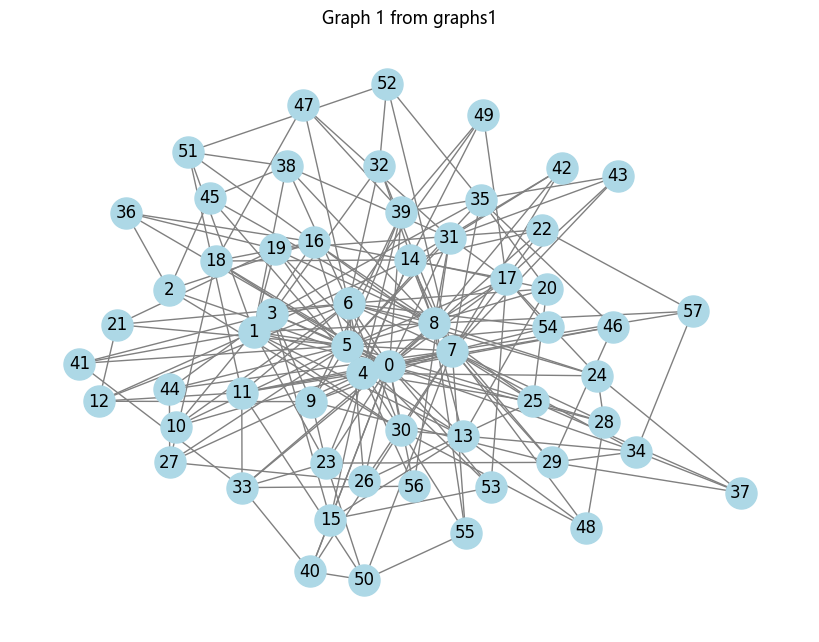

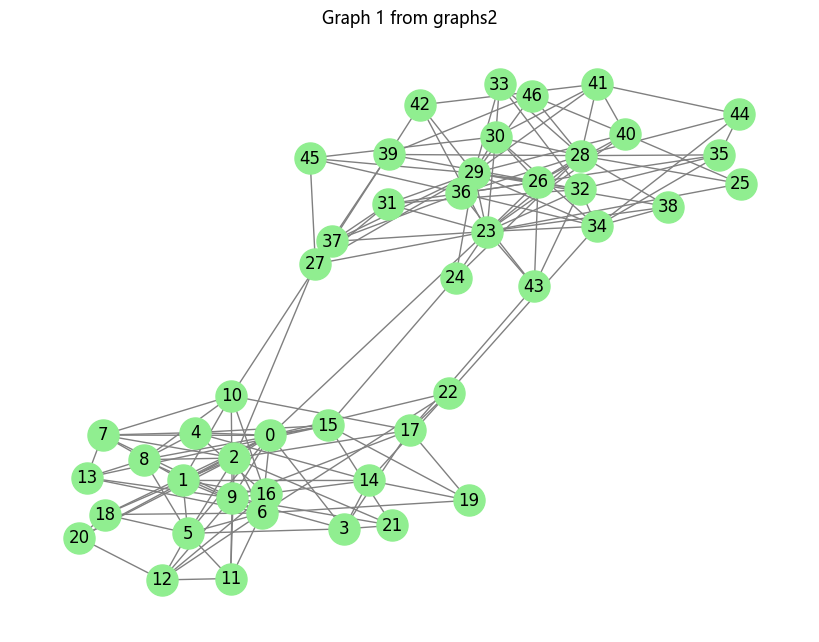

In [26]:
# 可视化 graphs1 中前5个图
for i, G in enumerate(graphs1_1[:1]):  # 这里显示前5个图
    plt.figure(figsize=(8, 6))
    nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500)
    plt.title(f"Graph {i+1} from graphs1")
    plt.show()

# 可视化 graphs2 中前5个图
for i, G in enumerate(graphs1_2[:1]):  # 这里显示前5个图
    plt.figure(figsize=(8, 6))
    nx.draw(G, with_labels=True, node_color='lightgreen', edge_color='gray', node_size=500)
    plt.title(f"Graph {i+1} from graphs2")
    plt.show()

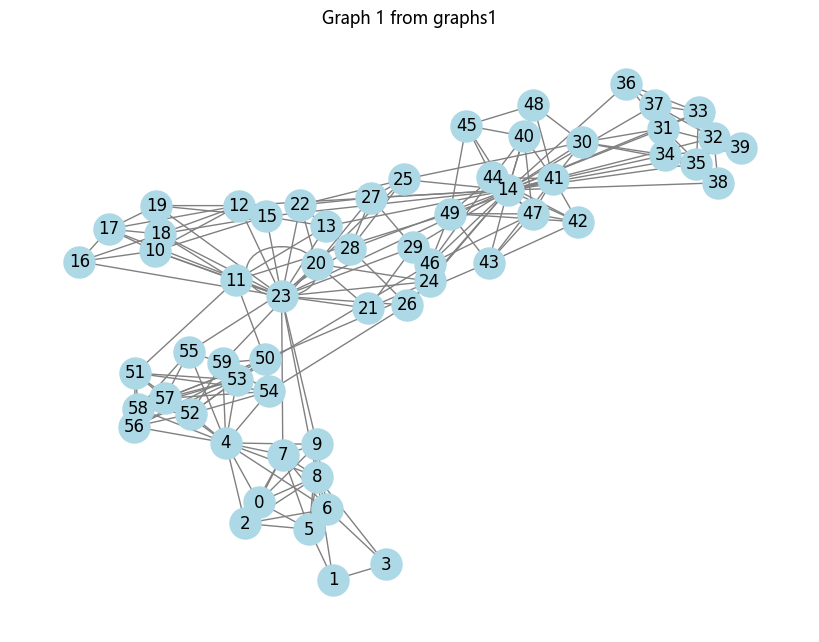

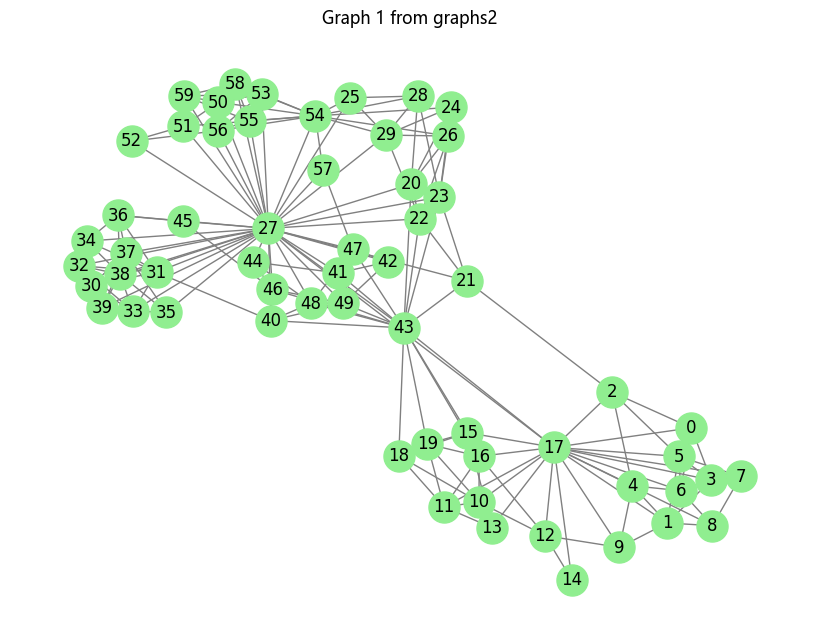

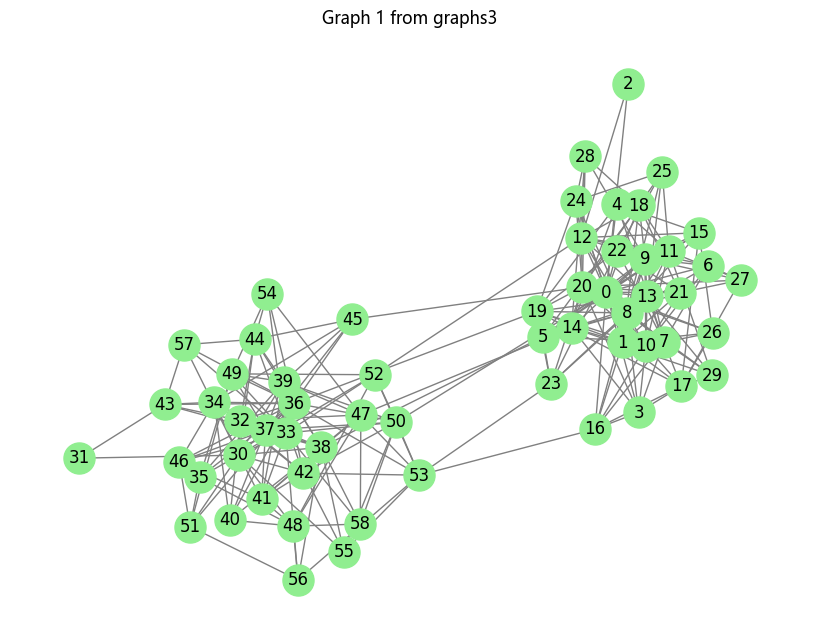

In [27]:
# 可视化 graphs1 中前5个图
for i, G in enumerate(graphs2_1[:1]):  # 这里显示前5个图
    plt.figure(figsize=(8, 6))
    nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500)
    plt.title(f"Graph {i+1} from graphs1")
    plt.show()

# 可视化 graphs2 中前5个图
for i, G in enumerate(graphs2_2[:1]):  # 这里显示前5个图
    plt.figure(figsize=(8, 6))
    nx.draw(G, with_labels=True, node_color='lightgreen', edge_color='gray', node_size=500)
    plt.title(f"Graph {i+1} from graphs2")
    plt.show()

# 可视化 graphs2 中前5个图
for i, G in enumerate(graphs2_3[:1]):  # 这里显示前5个图
    plt.figure(figsize=(8, 6))
    nx.draw(G, with_labels=True, node_color='lightgreen', edge_color='gray', node_size=500)
    plt.title(f"Graph {i+1} from graphs3")
    plt.show()
